In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from probcs.models.pattern_completion_model import ExpPatternCompletionModel
from probcs.experiment_running.exc_experiment import (
    center_surround_experiment,
    create_stimuli,
)
import arviz as az
from sklearn.metrics.pairwise import cosine_similarity
from probcs.utils.utils import select_focus_images, get_excitatory_images

seed = 42
rng = np.random.default_rng(seed)

In [10]:
basepath = Path("/src/project/data/experiment")
custom_crop_path = basepath / "custom_centered_exc_crops.npy"
patterns = np.load(custom_crop_path)

In [11]:
patterns = patterns - patterns.mean(axis=0)
vmin = patterns.min()
vmax = patterns.max()

In [28]:
G_dim = len(patterns)
G_prob = 1 / G_dim / 2
x_sigma = 0.5
I_sigma = 30
offset = 4
scale_offset = 2
scale_exponent = 2
G_X_exponent = 4
G_visual_nrows = G_dim
G_visual_ncols = 1
x_visual_nrows = G_dim
x_visual_ncols = 9
n_tune = 300
n_draws = 300
n_chains = 4
n_cores = 4

In [29]:
model = ExpPatternCompletionModel(
    patterns=patterns,
    G_prob=G_prob,
    X_sigma=x_sigma,
    I_sigma=I_sigma,
    patterns_offset=offset,
    G_X_exponent=G_X_exponent,
    scale_offset=scale_offset,
    scale_exponent=scale_exponent,
)
cossim = cosine_similarity(model.patterns.reshape(model.patterns.shape[0], -1))

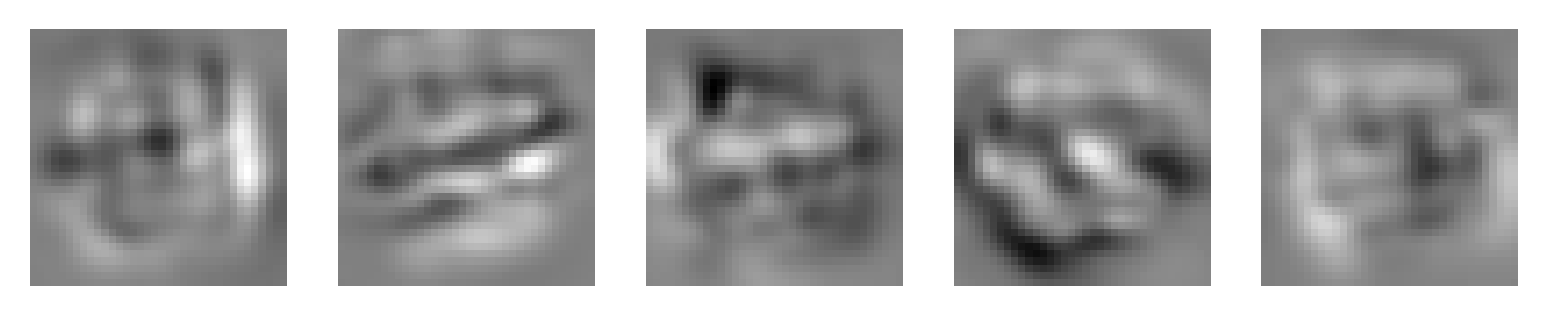

In [30]:
fig, axs = plt.subplots(1, G_dim, dpi=300)
for ax, pattern in zip(axs.flatten(), patterns):
    ax.imshow(pattern, cmap="gray", vmin=vmin, vmax=vmax)
    ax.axis("off")

Text(0.5, 1.0, 'Cos sim between assigned Gs')

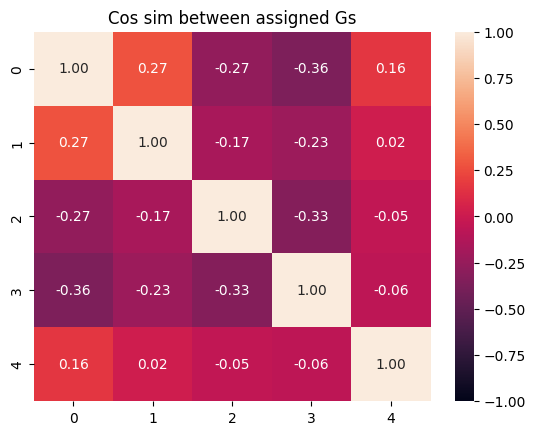

In [31]:
fig, ax = plt.subplots(dpi=100)
sns.heatmap(cossim, vmin=-1, vmax=1, annot=True, fmt=".2f", ax=ax)
ax.set_title("Cos sim between assigned Gs")